# HOUSE PRICE PREDICTION DATASET

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [4]:
df.shape

(2000, 10)

In [5]:
df.size

20000

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [8]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [9]:
df['Location'].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [10]:
df['Condition'].value_counts()

Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

In [11]:
df['Garage'].value_counts()

Garage
No     1038
Yes     962
Name: count, dtype: int64

In [12]:
df.corr(numeric_only=True)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


<Axes: >

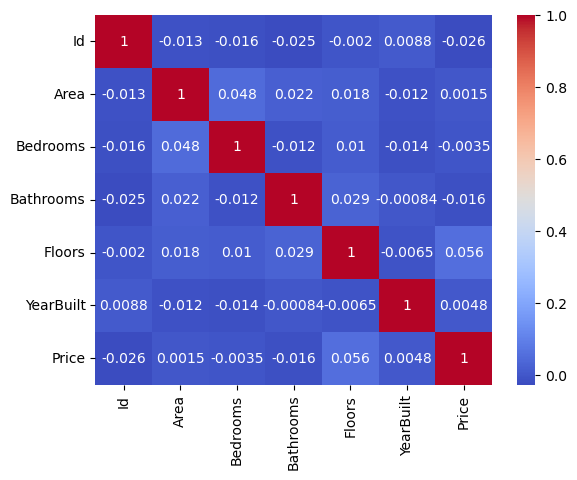

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

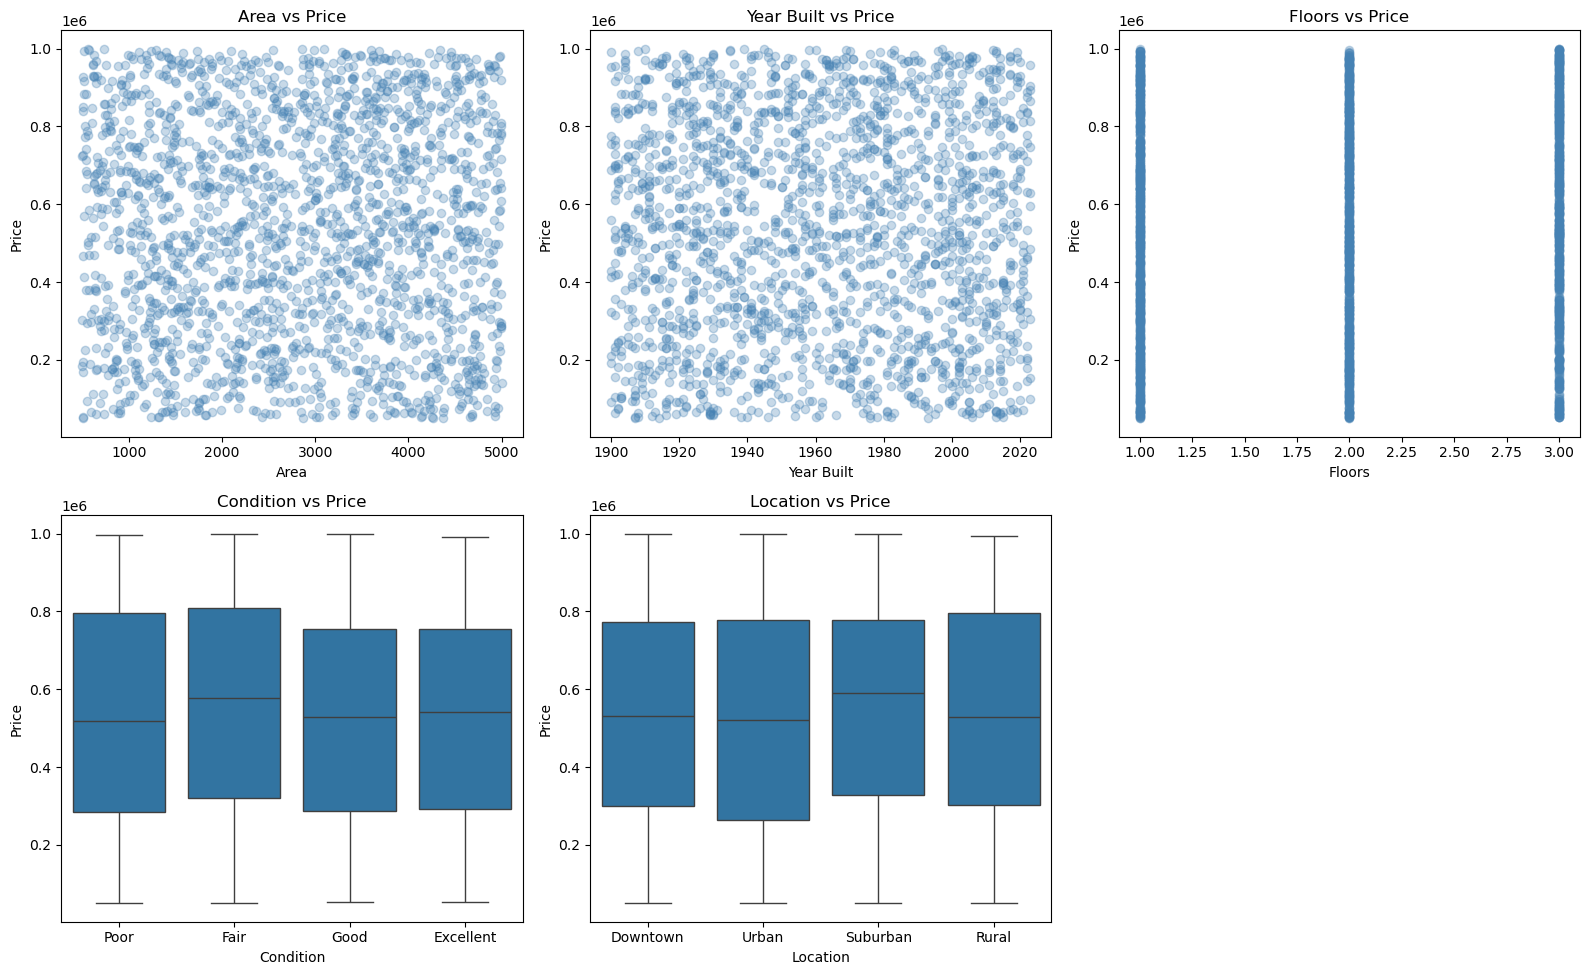

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Area vs Price
axes[0,0].scatter(df['Area'], df['Price'], alpha=0.3, color='steelblue')
axes[0,0].set_title("Area vs Price")
axes[0,0].set_xlabel("Area")
axes[0,0].set_ylabel("Price")

# 2. YearBuilt vs Price
axes[0,1].scatter(df['YearBuilt'], df['Price'], alpha=0.3, color='steelblue')
axes[0,1].set_title("Year Built vs Price")
axes[0,1].set_xlabel("Year Built")
axes[0,1].set_ylabel("Price")

# 3. Floors vs Price
axes[0,2].scatter(df['Floors'], df['Price'], alpha=0.3, color='steelblue')
axes[0,2].set_title("Floors vs Price")
axes[0,2].set_xlabel("Floors")
axes[0,2].set_ylabel("Price")

# 4. Condition vs Price (boxplot)
condition_order = ['Poor', 'Fair', 'Good', 'Excellent']
sns.boxplot(data=df, x='Condition', y='Price', order=condition_order, ax=axes[1,0])
axes[1,0].set_title("Condition vs Price")

# 5. Location vs Price (boxplot)
location_order = ['Downtown', 'Urban', 'Suburban', 'Rural']
sns.boxplot(data=df, x='Location', y='Price', order=location_order, ax=axes[1,1])
axes[1,1].set_title("Location vs Price")

axes[1,2].set_visible(False)

plt.suptitle("") 
plt.tight_layout()
plt.show()